
# 04 Performance Analytics

Day 4 of the Bluestock capstone focuses on institutional-grade mutual fund performance analytics.

This notebook:
- Loads `dim_fund` and `fact_nav` from the local SQLite star schema
- Aligns fund timelines with `NIFTY50` and `NIFTY100` benchmark data from `data/raw/10_benchmark_indices.csv`
- Computes return, risk, and regression metrics for all 40 schemes
- Builds a weighted scorecard and alpha/beta risk table
- Exports a benchmark comparison chart for the top 5 ranked schemes



## Data Preparation and Benchmark Alignment

The performance model uses the daily NAV history stored in the local database and the benchmark series in the raw market file.

Key conventions:
- SQLite source: `../data/db/bluestock_mf.db`
- Raw market source: `../data/raw/10_benchmark_indices.csv`
- Output tables: `../data/processed/fund_scorecard.csv` and `../data/processed/alpha_beta.csv`
- Chart export: `../reports/00_benchmark_comparison.png`


In [1]:

from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120

BASE_DIR = Path('..')
if not (BASE_DIR / 'data' / 'db' / 'bluestock_mf.db').exists():
    BASE_DIR = Path('.')

DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REPORTS_DIR = BASE_DIR / 'reports'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
RISK_FREE_RATE = 0.065
TOP_N = 5
COMPARISON_WINDOW = 756

conn = sqlite3.connect(DB_PATH.as_posix())

# Pull the star-schema tables from SQLite.
dim_fund = pd.read_sql_query('SELECT * FROM dim_fund', conn)
fact_nav = pd.read_sql_query('SELECT * FROM fact_nav', conn, parse_dates=['nav_date'])
conn.close()

# Pull the benchmark series from the raw market file.
benchmark_raw = pd.read_csv(RAW_DIR / '10_benchmark_indices.csv')
benchmark_raw['date'] = pd.to_datetime(benchmark_raw['date'])
benchmark_raw = benchmark_raw[benchmark_raw['index_name'].isin(['NIFTY50', 'NIFTY100'])].copy()
benchmark_wide = (
    benchmark_raw.pivot_table(
        index='date',
        columns='index_name',
        values='close_value',
        aggfunc='last',
    )
    .reset_index()
    .sort_values('date')
    .reset_index(drop=True)
)
benchmark_wide['NIFTY50_return'] = benchmark_wide['NIFTY50'].pct_change()
benchmark_wide['NIFTY100_return'] = benchmark_wide['NIFTY100'].pct_change()

# Merge the fund-level NAV history with scheme metadata.
fund_nav = (
    fact_nav.merge(dim_fund, on='amfi_code', how='inner')
    .sort_values(['amfi_code', 'nav_date'])
    .reset_index(drop=True)
)

print(f'Dim fund shape: {dim_fund.shape}')
print(f'Fact NAV shape: {fact_nav.shape}')
print(f'Fund NAV merged shape: {fund_nav.shape}')
print(f'Benchmark rows after filtering: {benchmark_wide.shape[0]}')
print(f'Date range in NAV data: {fund_nav["nav_date"].min().date()} -> {fund_nav["nav_date"].max().date()}')
print(f'Date range in benchmark data: {benchmark_wide["date"].min().date()} -> {benchmark_wide["date"].max().date()}')


Dim fund shape: (40, 7)
Fact NAV shape: (64320, 4)
Fund NAV merged shape: (64320, 10)
Benchmark rows after filtering: 1150
Date range in NAV data: 2022-01-03 -> 2026-05-29
Date range in benchmark data: 2022-01-03 -> 2026-05-29



## Quantitative Framework

This section applies vectorized finance formulas to every scheme:
- Daily returns from NAV percent change
- 1-year, 3-year, and 5-year CAGR using active session counts
- Sharpe and Sortino ratios with a 6.5% annual risk-free proxy
- Alpha and beta from OLS regression against `NIFTY100`
- Maximum drawdown with peak and trough date capture


In [2]:


def annualized_cagr(nav_series: pd.Series, window_sessions: int) -> float:
    nav_series = nav_series.dropna()
    if len(nav_series) < window_sessions:
        return np.nan

    window = nav_series.iloc[-window_sessions:]
    start_value = float(window.iloc[0])
    end_value = float(window.iloc[-1])
    if start_value <= 0 or end_value <= 0:
        return np.nan

    return (end_value / start_value) ** (TRADING_DAYS / len(window)) - 1


def sharpe_ratio(daily_returns: pd.Series) -> float:
    daily_returns = daily_returns.dropna()
    if daily_returns.empty:
        return np.nan

    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    excess_returns = daily_returns - rf_daily
    vol = daily_returns.std(ddof=1)
    if pd.isna(vol) or vol == 0:
        return np.nan

    return excess_returns.mean() / vol * np.sqrt(TRADING_DAYS)


def sortino_ratio(daily_returns: pd.Series) -> float:
    daily_returns = daily_returns.dropna()
    if daily_returns.empty:
        return np.nan

    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    excess_returns = daily_returns - rf_daily
    downside_returns = daily_returns[daily_returns < 0]
    downside_vol = downside_returns.std(ddof=1)
    if pd.isna(downside_vol) or downside_vol == 0:
        return np.nan

    return excess_returns.mean() / downside_vol * np.sqrt(TRADING_DAYS)


def max_drawdown_summary(nav_series: pd.Series) -> dict:
    nav_series = nav_series.dropna().sort_index()
    if nav_series.empty:
        return {
            'max_drawdown_pct': np.nan,
            'peak_date': pd.NaT,
            'trough_date': pd.NaT,
            'peak_nav': np.nan,
            'trough_nav': np.nan,
        }

    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    trough_date = drawdown.idxmin()
    peak_window = nav_series.loc[:trough_date]
    peak_date = peak_window.idxmax()

    return {
        'max_drawdown_pct': float(drawdown.loc[trough_date] * 100),
        'peak_date': peak_date,
        'trough_date': trough_date,
        'peak_nav': float(nav_series.loc[peak_date]),
        'trough_nav': float(nav_series.loc[trough_date]),
    }


def tracking_error(fund_returns: pd.Series, benchmark_returns: pd.Series) -> float:
    aligned = pd.concat([fund_returns, benchmark_returns], axis=1, join='inner').dropna()
    if len(aligned) < 2:
        return np.nan

    diff = aligned.iloc[:, 0] - aligned.iloc[:, 1]
    return float(diff.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100)


def inverse_percentile(series: pd.Series) -> pd.Series:
    ranked = series.rank(method='average', pct=True)
    count = series.notna().sum()
    if count <= 1:
        return pd.Series(np.ones(len(series)), index=series.index)
    return 1 - ranked + (1 / count)


metric_rows = []
alpha_beta_rows = []
all_daily_return_series = []

for amfi_code, group in fund_nav.groupby('amfi_code', sort=True):
    group = group.sort_values('nav_date').reset_index(drop=True).copy()
    group['daily_return'] = group['nav'].pct_change()
    all_daily_return_series.append(group['daily_return'].dropna())

    nav_series = group.set_index('nav_date')['nav']
    daily_returns = group['daily_return'].dropna()

    cagr_1yr = annualized_cagr(nav_series, 252)
    cagr_3yr = annualized_cagr(nav_series, 756)
    cagr_5yr = annualized_cagr(nav_series, 1260)
    sharpe = sharpe_ratio(daily_returns)
    sortino = sortino_ratio(daily_returns)

    beta_panel = group[['nav_date', 'daily_return']].merge(
        benchmark_wide[['date', 'NIFTY100_return']],
        left_on='nav_date',
        right_on='date',
        how='inner',
    ).dropna(subset=['daily_return', 'NIFTY100_return'])

    if len(beta_panel) >= 2:
        regression = linregress(beta_panel['NIFTY100_return'], beta_panel['daily_return'])
        beta = float(regression.slope)
        alpha = float(regression.intercept * TRADING_DAYS)
        r_squared = float(regression.rvalue ** 2)
    else:
        beta = np.nan
        alpha = np.nan
        r_squared = np.nan

    drawdown = max_drawdown_summary(nav_series)
    meta = group.iloc[0]

    metric_rows.append({
        'amfi_code': int(amfi_code),
        'scheme_name': meta['scheme_name'],
        'fund_house': meta['fund_house'],
        'category': meta['category'],
        'sub_category': meta['sub_category'],
        'risk_category': meta['risk_category'],
        'expense_ratio_pct': float(meta['expense_ratio_pct']),
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha': alpha,
        'beta': beta,
        'r_squared': r_squared,
        'max_drawdown_pct': drawdown['max_drawdown_pct'],
        'drawdown_depth_pct': abs(drawdown['max_drawdown_pct']),
        'peak_date': drawdown['peak_date'],
        'trough_date': drawdown['trough_date'],
        'peak_nav': drawdown['peak_nav'],
        'trough_nav': drawdown['trough_nav'],
        'n_obs': int(len(group)),
        'n_beta_obs': int(len(beta_panel)),
    })

    alpha_beta_rows.append({
        'amfi_code': int(amfi_code),
        'scheme_name': meta['scheme_name'],
        'fund_house': meta['fund_house'],
        'alpha': alpha,
        'beta': beta,
        'r_squared': r_squared,
        'n_beta_obs': int(len(beta_panel)),
    })

fund_metrics = pd.DataFrame(metric_rows)
alpha_beta = pd.DataFrame(alpha_beta_rows)

# Validate the return distribution across all funds.
all_daily_returns = pd.concat(all_daily_return_series, ignore_index=True)
print('Daily return distribution checks')
print(f'Count: {all_daily_returns.count()}')
print(f'Mean: {all_daily_returns.mean():.6f}')
print(f'Std: {all_daily_returns.std(ddof=1):.6f}')
print(f'Skewness: {all_daily_returns.skew():.4f}')
print(f'Kurtosis: {all_daily_returns.kurtosis():.4f}')
print()
print('Top drawdown observations by fund:')
print(fund_metrics[['scheme_name', 'max_drawdown_pct', 'peak_date', 'trough_date']].sort_values('max_drawdown_pct').head(5).to_string(index=False))


Daily return distribution checks
Count: 64280
Mean: 0.000451
Std: 0.008706
Skewness: 0.1123
Kurtosis: 3.1018

Top drawdown observations by fund:
                               scheme_name  max_drawdown_pct  peak_date trough_date
 SBI Small Cap Fund - Direct Plan - Growth        -52.574221 2023-01-17  2025-10-28
    Axis Small Cap Fund - Regular - Growth        -51.677754 2025-05-22  2026-05-11
    ABSL Small Cap Fund - Regular - Growth        -35.446916 2024-11-21  2026-05-11
     DSP Small Cap Fund - Regular - Growth        -31.171900 2024-05-03  2025-01-03
SBI Small Cap Fund - Regular Plan - Growth        -28.706006 2024-08-28  2025-05-14



## Scorecard Construction and Export

The composite score uses percentile ranks across the selected metrics:
- 30%: 3-year CAGR
- 25%: Sharpe ratio
- 20%: Alpha
- 15%: Expense ratio, inverted so lower fees score higher
- 10%: Maximum drawdown depth, inverted so shallower drawdowns score higher


In [3]:

scorecard = fund_metrics.copy()

scorecard['pct_cagr_3yr'] = scorecard['cagr_3yr'].rank(method='average', pct=True)
scorecard['pct_sharpe'] = scorecard['sharpe_ratio'].rank(method='average', pct=True)
scorecard['pct_alpha'] = scorecard['alpha'].rank(method='average', pct=True)
scorecard['pct_expense_inv'] = inverse_percentile(scorecard['expense_ratio_pct'])
scorecard['pct_drawdown_inv'] = inverse_percentile(scorecard['drawdown_depth_pct'])

scorecard['composite_score'] = (
    0.30 * scorecard['pct_cagr_3yr']
    + 0.25 * scorecard['pct_sharpe']
    + 0.20 * scorecard['pct_alpha']
    + 0.15 * scorecard['pct_expense_inv']
    + 0.10 * scorecard['pct_drawdown_inv']
) * 100

scorecard['score_rank'] = scorecard['composite_score'].rank(method='dense', ascending=False).astype(int)
scorecard = scorecard.sort_values(['score_rank', 'composite_score'], ascending=[True, False]).reset_index(drop=True)

alpha_beta = alpha_beta.sort_values('amfi_code').reset_index(drop=True)

fund_scorecard_path = PROCESSED_DIR / 'fund_scorecard.csv'
alpha_beta_path = PROCESSED_DIR / 'alpha_beta.csv'

scorecard.to_csv(fund_scorecard_path, index=False)
alpha_beta.to_csv(alpha_beta_path, index=False)

print(f'Exported scorecard to: {fund_scorecard_path}')
print(f'Exported alpha/beta table to: {alpha_beta_path}')
print()
print('Top 10 scorecard rows:')
print(scorecard[['score_rank', 'amfi_code', 'scheme_name', 'fund_house', 'composite_score', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown_pct']].head(10).to_string(index=False))
print()
print('Alpha/Beta snapshot:')
print(alpha_beta.head(10).to_string(index=False))


Exported scorecard to: ../data/processed/fund_scorecard.csv
Exported alpha/beta table to: ../data/processed/alpha_beta.csv

Top 10 scorecard rows:
 score_rank  amfi_code                                        scheme_name               fund_house  composite_score  cagr_3yr  sharpe_ratio    alpha      beta  max_drawdown_pct
          1     148567      Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF          86.2500  0.251275      1.068224 0.269838  0.023684        -11.265729
          2     120843             Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF          82.7500  0.216700      0.965561 0.273305 -0.022830        -12.973968
          3     100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund          80.7500  0.244077      0.808268 0.271954  0.005104        -16.217209
          4     119551          SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund          77.9375  0.285602      0.860977 0.232


## Benchmark Comparison Visualization

The plot below compares the top 5 scored schemes against `NIFTY50` and `NIFTY100` using a hypothetical ₹10,000 investment over the most recent 3-year aligned trading window.

Tracking error is reported in the annotation box as annualized percentage volatility of fund-minus-benchmark return spreads.


/var/folders/4b/0dx9_rf97hd3201xytvqg84m0000gn/T/ipykernel_18491/1664196920.py:102: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 0.78, 1])
/var/folders/4b/0dx9_rf97hd3201xytvqg84m0000gn/T/ipykernel_18491/1664196920.py:105: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.savefig(chart_path, dpi=300, bbox_inches='tight')
/Users/sayonmanna/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


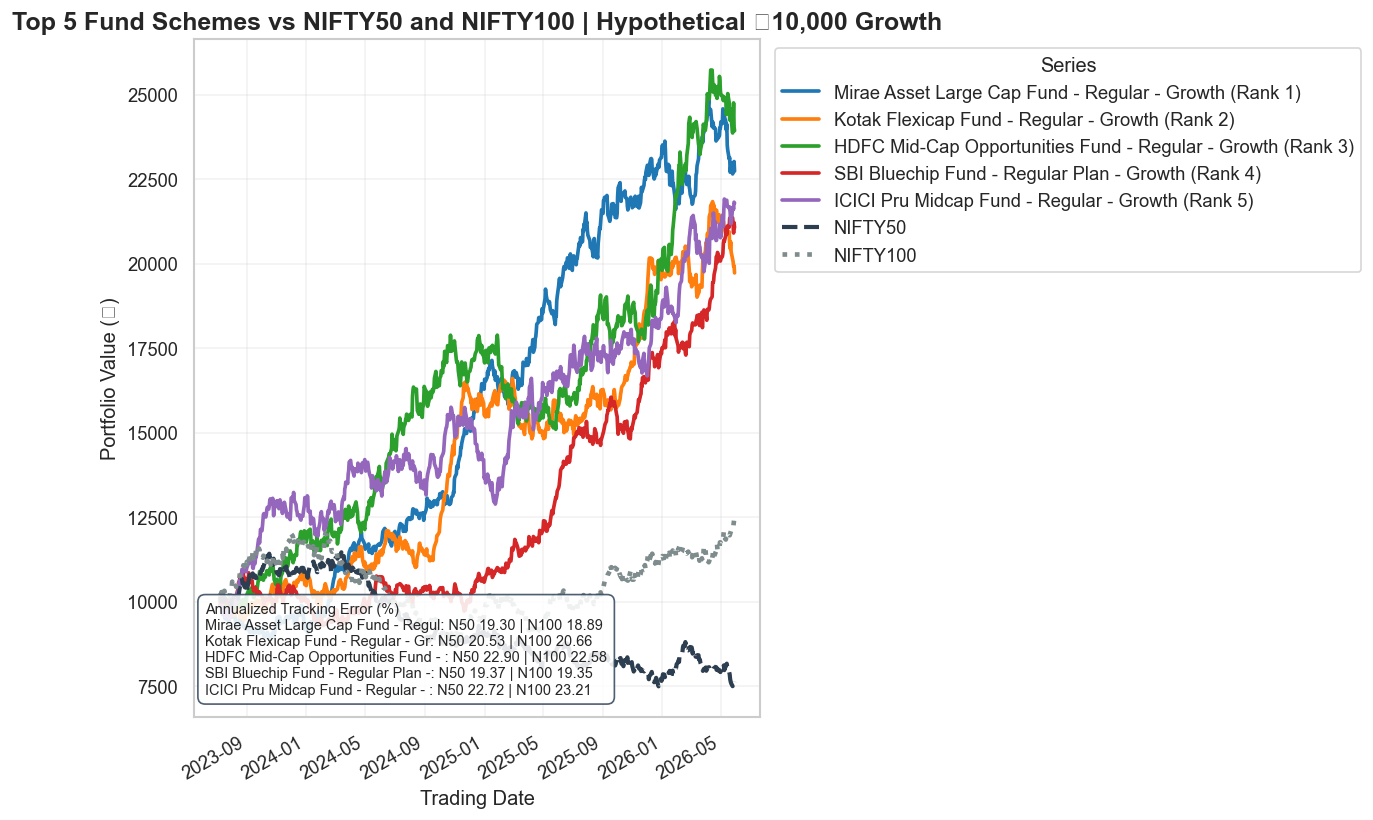

Comparison chart saved to: ../reports/00_benchmark_comparison.png

Tracking error table:
                                       scheme_name  amfi_code  te_nifty50_pct  te_nifty100_pct  score_rank  composite_score
     Mirae Asset Large Cap Fund - Regular - Growth     148567       19.297948        18.892805           1          86.2500
            Kotak Flexicap Fund - Regular - Growth     120843       20.530605        20.664603           2          82.7500
HDFC Mid-Cap Opportunities Fund - Regular - Growth     100033       22.897046        22.580598           3          80.7500
         SBI Bluechip Fund - Regular Plan - Growth     119551       19.366221        19.348429           4          77.9375
          ICICI Pru Midcap Fund - Regular - Growth     120505       22.720856        23.210087           5          76.8750


In [4]:

# Build the top-5 comparison panel against both benchmarks.
top5 = scorecard.head(TOP_N).copy()
comparison_rows = []
tracking_rows = []

for _, row in top5.iterrows():
    amfi_code = int(row['amfi_code'])
    scheme_name = row['scheme_name']

    fund_panel = fund_nav.loc[fund_nav['amfi_code'] == amfi_code, ['nav_date', 'nav']].sort_values('nav_date')
    panel = (
        benchmark_wide[['date', 'NIFTY50_return', 'NIFTY100_return']]
        .merge(fund_panel, left_on='date', right_on='nav_date', how='inner')
        .sort_values('date')
        .reset_index(drop=True)
    )
    panel['fund_return'] = panel['nav'].pct_change()
    panel = panel.dropna(subset=['fund_return', 'NIFTY50_return', 'NIFTY100_return']).copy()
    panel = panel.tail(COMPARISON_WINDOW).reset_index(drop=True)

    panel['fund_growth'] = 10000 * (1 + panel['fund_return']).cumprod()
    panel['NIFTY50_growth'] = 10000 * (1 + panel['NIFTY50_return']).cumprod()
    panel['NIFTY100_growth'] = 10000 * (1 + panel['NIFTY100_return']).cumprod()
    panel['scheme_name'] = scheme_name
    panel['amfi_code'] = amfi_code

    te_nifty50 = tracking_error(panel['fund_return'], panel['NIFTY50_return'])
    te_nifty100 = tracking_error(panel['fund_return'], panel['NIFTY100_return'])

    comparison_rows.append(panel)
    tracking_rows.append({
        'scheme_name': scheme_name,
        'amfi_code': amfi_code,
        'te_nifty50_pct': te_nifty50,
        'te_nifty100_pct': te_nifty100,
        'score_rank': int(row['score_rank']),
        'composite_score': float(row['composite_score']),
    })

comparison_df = pd.concat(comparison_rows, ignore_index=True)
tracking_df = pd.DataFrame(tracking_rows)

fig, ax = plt.subplots(figsize=(14, 7))
fund_palette = sns.color_palette('tab10', n_colors=TOP_N)
index_colors = {'NIFTY50': '#2c3e50', 'NIFTY100': '#7f8c8d'}

for idx, (_, row) in enumerate(top5.iterrows()):
    fund_panel = comparison_df.loc[comparison_df['amfi_code'] == int(row['amfi_code'])].copy()
    label = f"{row['scheme_name']} (Rank {int(row['score_rank'])})"
    ax.plot(
        fund_panel['date'],
        fund_panel['fund_growth'],
        color=fund_palette[idx],
        linewidth=2.2,
        label=label,
    )

# Plot the benchmark reference curves using the first aligned comparison frame.
reference_panel = comparison_df.loc[comparison_df['amfi_code'] == int(top5.iloc[0]['amfi_code'])].copy()
ax.plot(
    reference_panel['date'],
    reference_panel['NIFTY50_growth'],
    color=index_colors['NIFTY50'],
    linestyle='--',
    linewidth=2.5,
    label='NIFTY50',
)
ax.plot(
    reference_panel['date'],
    reference_panel['NIFTY100_growth'],
    color=index_colors['NIFTY100'],
    linestyle=':',
    linewidth=2.8,
    label='NIFTY100',
)

ax.set_title('Top 5 Fund Schemes vs NIFTY50 and NIFTY100 | Hypothetical ₹10,000 Growth', fontsize=15, weight='bold')
ax.set_xlabel('Trading Date')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=True, title='Series')

tracking_lines = ['Annualized Tracking Error (%)']
for _, row in tracking_df.iterrows():
    short_name = row['scheme_name'][:34]
    tracking_lines.append(
        f"{short_name}: N50 {row['te_nifty50_pct']:.2f} | N100 {row['te_nifty100_pct']:.2f}"
    )

ax.text(
    0.02,
    0.03,
    '\n'.join(tracking_lines),
    transform=ax.transAxes,
    fontsize=8.7,
    va='bottom',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.88, edgecolor='#34495e'),
)

ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 0.78, 1])

chart_path = REPORTS_DIR / '00_benchmark_comparison.png'
fig.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Comparison chart saved to: {chart_path}')
print()
print('Tracking error table:')
print(tracking_df.sort_values('score_rank').to_string(index=False))



## Export Summary

Completed outputs for Day 4 performance analytics:
- `../data/processed/fund_scorecard.csv`
- `../data/processed/alpha_beta.csv`
- `../reports/00_benchmark_comparison.png`
